# Core API Walkthrough

This notebook only uses the core client primitives. Analysis is plain NumPy in notebook cells.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(root))

from client.config import registry
from client.interface import SlopClient

print(registry.list())


[ProviderConfig(name='vast-32582479', kind='ssh', target='vast-32582479', remote_path='/root/slop', python_cmd='python3', container_image=None, num_workers=8)]


In [2]:
providers = registry.list()
assert providers, 'no providers registered'
cfg = providers[-1]
client = SlopClient(cfg)
client.connect()
print("Connected")
client.info()

[REMOTE STDERR] Welcome to vast.ai. If authentication fails, try again after a few seconds, and double check your ssh key.
[REMOTE STDERR] Have fun!


Connected


[REMOTE STDERR] [SERVER] 2026-03-09 14:01:54,440 - INFO - server ready


ServerInfo(kind='info', job_id='5719ec547da7', timestamp=1773064915.0414302, elapsed_s=0.0, hostname='6d4c5ec935f6', gpu_name='NVIDIA GeForce RTX 3090', gpu_memory_mb=24122, cuda_version='12.8', torch_version='2.10.0+cu128', loaded_models=[], capabilities=['sample', 'render', 'batch', 'encode', 'probe'])

In [3]:
embeddings = client.encode(['a person', 'a warrior'])
embeddings.shape

Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  7.10it/s], ?it/s]


(2, 77, 768)

In [4]:
sample = client.sample(
    prompt='a person standing in a field',
    batch_size=2,
    num_steps=4,
)
sample.points.shape, sample.forces.shape

[REMOTE STDERR] [SERVER] 2026-03-09 14:02:05,944 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5
100%|██████████| 4/4 [00:00<00:00,  6.74it/s]?it/s]


((5, 4, 4, 64, 64), (5, 4, 4, 64, 64))

In [5]:
points = sample.points[-1]
probe = client.probe(points, prompt='a person', timestep=500)
delta = client.probe_delta(points, prompt_a='a person', prompt_b='a warrior', timestep=500)
probe.shape, delta.shape

[REMOTE STDERR] [SERVER] 2026-03-09 14:02:15,735 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5
[REMOTE STDERR] [SERVER] 2026-03-09 14:02:22,188 - INFO - sample/probe request model=runwayml/stable-diffusion-v1-5


((4, 4, 64, 64), (4, 4, 64, 64))

[REMOTE STDERR] Welcome to vast.ai. If authentication fails, try again after a few seconds, and double check your ssh key.
[REMOTE STDERR] Have fun!
[REMOTE STDERR] [SERVER] 2026-03-09 14:05:24,258 - INFO - server ready
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  6.51it/s], ?it/s]


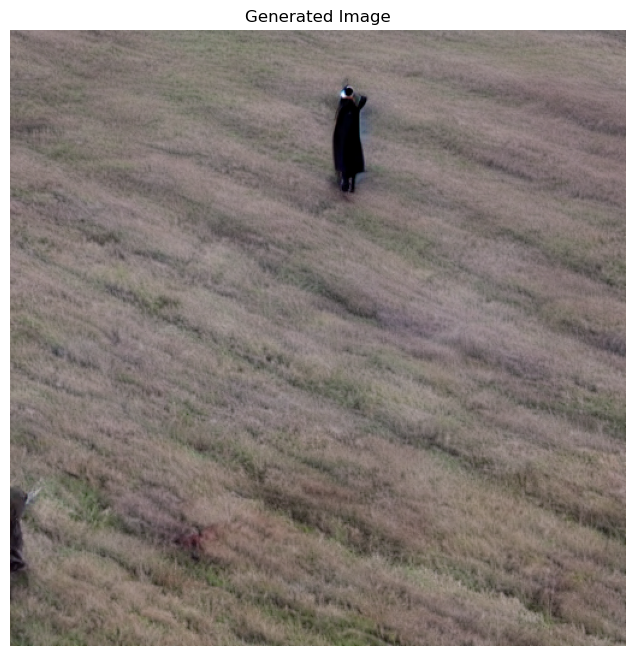

In [10]:
images = client.render(points)
len(images)

plt.figure(figsize=(8, 8))
plt.imshow(images[0])
plt.axis('off')
plt.title('Generated Image')
plt.show()

In [11]:
flat = delta.reshape(delta.shape[0], -1)
norms = np.linalg.norm(flat, axis=1)
norms

array([ 9.  , 11.55,  9.  , 11.55], dtype=float16)

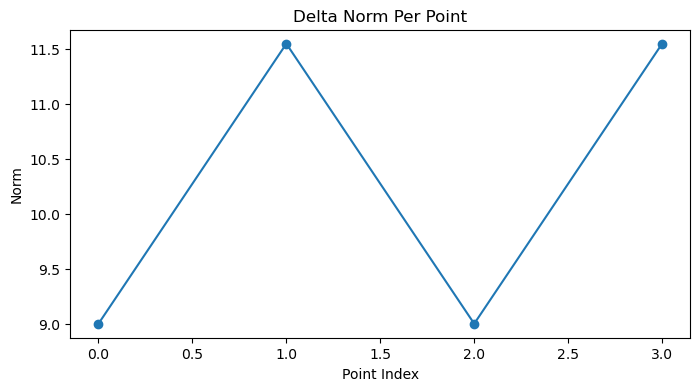

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(norms, marker='o')
plt.title('Delta Norm Per Point')
plt.xlabel('Point Index')
plt.ylabel('Norm')
plt.show()

In [13]:
client.close()